<a href="https://colab.research.google.com/github/Gajalakshmi993/Forest-cover-Type-Prediction/blob/main/Forest_cover_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
df = pd.read_csv('/content/cover_type.csv')
df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type,Wilderness_Area,Soil_Type
0,2596,51,3,258,0,510,221,232,148,6279,Aspen,1,29
1,2590,56,2,212,-6,390,220,235,151,6225,Aspen,1,29
2,2804,139,9,268,65,3180,234,238,135,6121,Lodgepole Pine,1,12
3,2785,155,18,242,118,3090,238,238,122,6211,Lodgepole Pine,1,30
4,2595,45,2,153,-1,391,220,234,150,6172,Aspen,1,29


In [3]:
df.shape

(145890, 13)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145890 entries, 0 to 145889
Data columns (total 13 columns):
 #   Column                              Non-Null Count   Dtype 
---  ------                              --------------   ----- 
 0   Elevation                           145890 non-null  int64 
 1   Aspect                              145890 non-null  int64 
 2   Slope                               145890 non-null  int64 
 3   Horizontal_Distance_To_Hydrology    145890 non-null  int64 
 4   Vertical_Distance_To_Hydrology      145890 non-null  int64 
 5   Horizontal_Distance_To_Roadways     145890 non-null  int64 
 6   Hillshade_9am                       145890 non-null  int64 
 7   Hillshade_Noon                      145890 non-null  int64 
 8   Hillshade_3pm                       145890 non-null  int64 
 9   Horizontal_Distance_To_Fire_Points  145890 non-null  int64 
 10  Cover_Type                          145890 non-null  object
 11  Wilderness_Area                     145

In [5]:
df.describe()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area,Soil_Type
count,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000
mean,2874.458949,141.127418,11.925574,251.824738,34.554322,3313.827541,217.368106,224.874748,139.788203,3044.958105,1.186593,23.364905
std,210.801279,107.719296,6.319326,192.473899,41.215776,1687.779953,21.590298,16.084851,31.311690,1761.882341,0.656571,8.215184
min,1863.000000,0.000000,0.000000,0.000000,-146.000000,0.000000,0.000000,99.000000,0.000000,0.000000,1.000000,1.000000
25%,2747.000000,54.000000,7.000000,95.000000,7.000000,1848.000000,207.000000,216.000000,121.000000,1608.000000,1.000000,12.000000
50%,2909.000000,108.000000,11.000000,212.000000,23.000000,3420.000000,222.000000,226.000000,140.000000,2713.000000,1.000000,29.000000
75%,3004.000000,217.000000,15.000000,362.000000,51.000000,4673.000000,232.000000,236.000000,159.000000,4478.000000,1.000000,29.000000
max,3849.000000,360.000000,61.000000,1343.000000,554.000000,7117.000000,254.000000,254.000000,248.000000,7173.000000,4.000000,40.000000


In [6]:
df.columns

Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Cover_Type', 'Wilderness_Area',
       'Soil_Type'],
      dtype='object')

In [7]:
for col in df.columns:
  print(f"{col}:\n Unique values:",df[col].nunique(),"\n", df[col].unique())
  print()
  print()

Elevation:
 Unique values: 1665 
 [2596 2590 2804 ... 3504 3510 3604]


Aspect:
 Unique values: 361 
 [ 51  56 139 155  45 132  49  59 201 151 134 214 157 259  72   0  38  71
 209 114  54  22 135 163 148 117 122 105 102  23  41 125  92  98 354 347
 346 330 128  68  94  99  66 100 323  79  81 315  74  11  42  75 107  90
  40  63  13  80 166   6  30 118 160 326 153 143 352  14 358 332  18 306
 173  31 164  34  84 170 211  32  57 348 333 324  88 111  53  58  76  17
 124 119 320 112  83   1  37 356 307   7  12 344 228 284 299 220   2  95
 289  21  20 200 349 328 221 257 276 196 189 130 357  15   8 288 129  28
  86 292 115  29 180 116  46 256 338 127 319  89  43 188  50 138 312   9
  10  36 167 260 187 279 245  27 359  16  48 149  60  77 230 152  70 325
 126 222 109  85  25 176 144 175 162  73  39  78 331 329 355  87 285 108
 106  24  52 261 232 246 342  61 141 216 236 254 336 278  62 237 281  69
 251 150 185 110 103 243 215 238 317 252 136 131 133 123 120 351 202 194
 101 282 258 270  65 2

In [8]:
df[df.duplicated()].sum() #Duplicate Check

,0
Elevation,0
Aspect,0
Slope,0
Horizontal_Distance_To_Hydrology,0
Vertical_Distance_To_Hydrology,0
Horizontal_Distance_To_Roadways,0
Hillshade_9am,0
Hillshade_Noon,0
Hillshade_3pm,0
Horizontal_Distance_To_Fire_Points,0


In [9]:
df.isna().sum() #null value check

,0
Elevation,0
Aspect,0
Slope,0
Horizontal_Distance_To_Hydrology,0
Vertical_Distance_To_Hydrology,0
Horizontal_Distance_To_Roadways,0
Hillshade_9am,0
Hillshade_Noon,0
Hillshade_3pm,0
Horizontal_Distance_To_Fire_Points,0


In [10]:
df["Cover_Type"].value_counts()

,count
Cover_Type,
Lodgepole Pine,103071
Spruce/Fir,31110
Aspen,3069
Krummholz,2160
Ponderosa Pine,2160
Douglas-fir,2160
Cottonwood/Willow,2160


In [11]:
df["Cover_Type"].value_counts(normalize=True) * 100

,proportion
Cover_Type,
Lodgepole Pine,70.649805
Spruce/Fir,21.324285
Aspen,2.103640
Krummholz,1.480568
Ponderosa Pine,1.480568
Douglas-fir,1.480568
Cottonwood/Willow,1.480568


In [12]:
df.columns

Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Cover_Type', 'Wilderness_Area',
       'Soil_Type'],
      dtype='object')

In [13]:
df[["Wilderness_Area"]].sum(axis=1).value_counts()


,count
1,134367
3,6349
4,4675
2,499


In [14]:
df[["Soil_Type"]].sum(axis=1).value_counts()

,count
29,60696
12,29144
30,18158
23,10150
20,6098
16,2219
24,2169
10,2142
18,1829
39,1210


In [15]:
from sklearn.impute import SimpleImputer
import numpy as np

num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

In [16]:
# Numeric → median
num_imputer = SimpleImputer(strategy="median")
df[num_cols] = num_imputer.fit_transform(df[num_cols])

# Categorical → mode
cat_imputer = SimpleImputer(strategy="most_frequent")
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])


In [17]:
continuous = ["Elevation", "Aspect", "Slope", "Hillshade_9am", "Hillshade_Noon", "Hillshade_3pm", "Horizontal_Distance_To_Hydrology", "Vertical_Distance_To_Hydrology",  "Horizontal_Distance_To_Roadways",  "Horizontal_Distance_To_Fire_Points"]
categorical = ["Cover_Type", "Wilderness_Area", "Soil_Type" ]

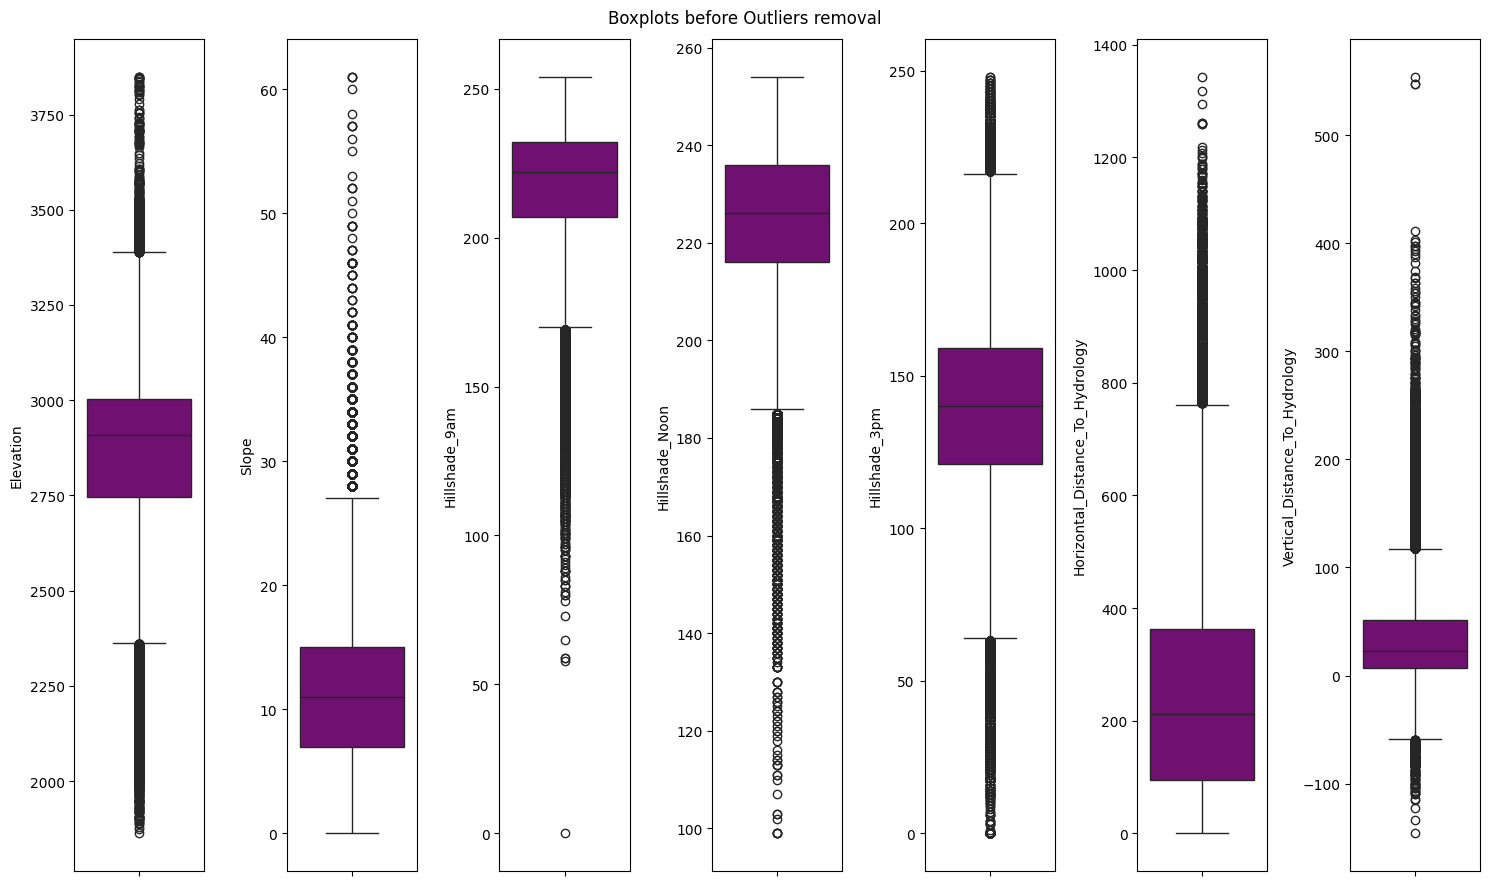

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
continuous1 = ["Elevation", "Slope", "Hillshade_9am", "Hillshade_Noon", "Hillshade_3pm", "Horizontal_Distance_To_Hydrology", "Vertical_Distance_To_Hydrology"]

# Loop through numerical columns and create boxplots

plt.figure(figsize=(15, 9))
plt.suptitle("Boxplots before Outliers removal")
for i in range(0, len(continuous1)):
    plt.subplot(1, 7, i+1)
    sns.boxplot(y=df[continuous1[i]],color='purple')
    plt.tight_layout()

In [19]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers.shape[0], lower_bound, upper_bound

In [20]:
for col in continuous1:
    count, lb, ub = detect_outliers_iqr(df, col)
    print(f"{col}: {count} outliers | Range [{lb:.2f}, {ub:.2f}]")

Elevation: 4448 outliers | Range [2361.50, 3389.50]
Slope: 3385 outliers | Range [-5.00, 27.00]
Hillshade_9am: 5242 outliers | Range [169.50, 269.50]
Hillshade_Noon: 3211 outliers | Range [186.00, 266.00]
Hillshade_3pm: 3087 outliers | Range [64.00, 216.00]
Horizontal_Distance_To_Hydrology: 2473 outliers | Range [-305.50, 762.50]
Vertical_Distance_To_Hydrology: 7123 outliers | Range [-59.00, 117.00]


In [21]:
df

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type,Wilderness_Area,Soil_Type
0,2596.0,51.0,3.0,258.0,0.0,510.0,221.0,232.0,148.0,6279.0,Aspen,1.0,29.0
1,2590.0,56.0,2.0,212.0,-6.0,390.0,220.0,235.0,151.0,6225.0,Aspen,1.0,29.0
2,2804.0,139.0,9.0,268.0,65.0,3180.0,234.0,238.0,135.0,6121.0,Lodgepole Pine,1.0,12.0
3,2785.0,155.0,18.0,242.0,118.0,3090.0,238.0,238.0,122.0,6211.0,Lodgepole Pine,1.0,30.0
4,2595.0,45.0,2.0,153.0,-1.0,391.0,220.0,234.0,150.0,6172.0,Aspen,1.0,29.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
145885,2834.0,88.0,8.0,376.0,44.0,2552.0,232.0,227.0,128.0,1595.0,Lodgepole Pine,1.0,29.0
145886,2832.0,68.0,4.0,390.0,44.0,2522.0,224.0,231.0,142.0,1572.0,Lodgepole Pine,1.0,29.0
145887,2829.0,80.0,7.0,390.0,33.0,2492.0,229.0,228.0,133.0,1550.0,Lodgepole Pine,1.0,29.0
145888,2826.0,121.0,7.0,379.0,30.0,2462.0,232.0,234.0,135.0,1528.0,Lodgepole Pine,1.0,29.0


In [22]:
df_capped = df.copy()

for col in continuous1:
    Q1 = df_capped[col].quantile(0.25)
    Q3 = df_capped[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_capped[col] = df_capped[col].clip(lower_bound, upper_bound)


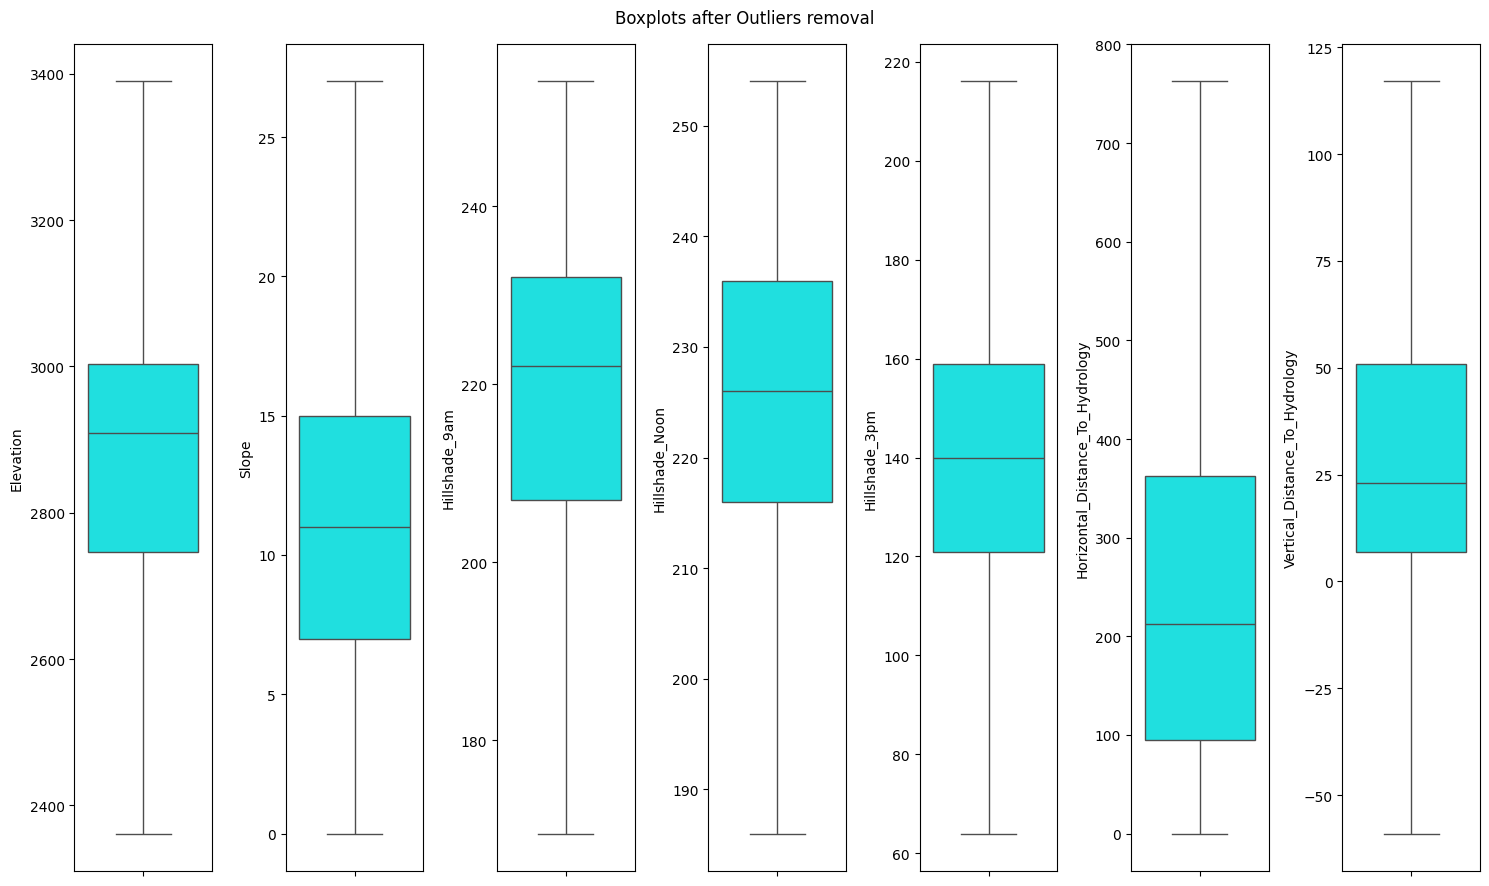

In [23]:
plt.figure(figsize=(15, 9))
plt.suptitle("Boxplots after Outliers removal")
for i in range(0, len(continuous1)):
    plt.subplot(1, 7, i+1)
    sns.boxplot(y=df_capped[continuous1[i]],color='cyan')
    plt.tight_layout()

In [24]:
df_capped.shape

(145890, 13)

In [25]:
from scipy import stats
for i in continuous:
    if df[i].skew()<0.5 and df[i].skew()>-0.5 and df[i].kurtosis()<3 and df[i].kurtosis()>-3:
        continue
    print("--------------------")
    print(i)
    method=[0,0.5,-0.5,1,-1,2,-2]
    for j in method:
      print(j)
      print("skewness",pd.DataFrame(stats.boxcox(df[i],lmbda=j)).skew().values[0],
            "kurtosis",pd.DataFrame(stats.boxcox(df[i],lmbda=j)).kurtosis().values[0])

--------------------
Elevation
0
skewness -1.0492873206966422 kurtosis 2.6769978649687625
0.5
skewness -0.8515064808124925 kurtosis 2.0653143953991346
-0.5
skewness -1.2597921721869523 kurtosis 3.4645299666860607
1
skewness -0.6644970564159847 kurtosis 1.608628077831285
-1
skewness -1.4849040625189966 kurtosis 4.453361204874634
2
skewness -0.3148500320084217 kurtosis 1.0999975223975955
-2
skewness 0.0 kurtosis 7.159165873511794
--------------------
Aspect
0
skewness nan kurtosis nan
0.5
skewness 0.06591753445081869 kurtosis -0.8536853144055709
-0.5
skewness nan kurtosis nan
1
skewness 0.6894319893052324 kurtosis -0.8172183946319302
-1
skewness nan kurtosis nan
2
skewness 1.247758562272491 kurtosis 0.07133017905530936
-2


/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1256: RuntimeWarning: invalid value encountered in subtract
  adjusted = values - mean
/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1344: RuntimeWarning: invalid value encountered in subtract
  adjusted = values - mean


skewness nan kurtosis nan
--------------------
Slope
0
skewness nan kurtosis nan
0.5
skewness 0.054626742165922344 kurtosis 0.2387376723741066
-0.5
skewness nan kurtosis nan
1
skewness 0.9439372721198183 kurtosis 1.3951242486422624
-1
skewness nan kurtosis nan
2
skewness 2.863165912550016 kurtosis 15.449643230888535
-2
skewness nan kurtosis nan
--------------------
Hillshade_9am
0
skewness nan kurtosis nan
0.5
skewness -1.58668973811709 kurtosis 4.724568563848707
-0.5
skewness nan kurtosis nan
1
skewness -1.2868386280334014 kurtosis 2.4971362622454167
-1
skewness nan kurtosis nan
2
skewness -0.872183691737844 kurtosis 0.882601480298288
-2
skewness nan kurtosis nan
--------------------
Hillshade_Noon
0
skewness -1.3932663222430937 kurtosis 4.741965206079976
0.5
skewness -1.1490943721418356 kurtosis 3.135769667364671
-0.5
skewness -1.6962681474341075 kurtosis 7.291807497767449
1
skewness -0.9454457286900354 kurtosis 2.0737997421922527
-1
skewness -2.087720844689729 kurtosis 11.5669087201

In [26]:
skewness = df[continuous].skew().sort_values(ascending=False)
skewness

,0
Vertical_Distance_To_Hydrology,1.792939
Horizontal_Distance_To_Hydrology,0.984953
Slope,0.943937
Aspect,0.689432
Horizontal_Distance_To_Fire_Points,0.365249
Horizontal_Distance_To_Roadways,-0.058240
Hillshade_3pm,-0.165213
Elevation,-0.664497
Hillshade_Noon,-0.945446
Hillshade_9am,-1.286839


In [27]:
df["Vertical_Distance_To_Hydrology"] = stats.boxcox(df["Vertical_Distance_To_Hydrology"],lmbda=0.5)
df["Hillshade_9am"] = stats.boxcox(df["Hillshade_9am"],lmbda=0.5)

In [28]:
import plotly.express as px
import numpy as np
px.scatter(df, x="Elevation",y="Slope",labels={'x':'First','y':'Second'},title="data_scatter")

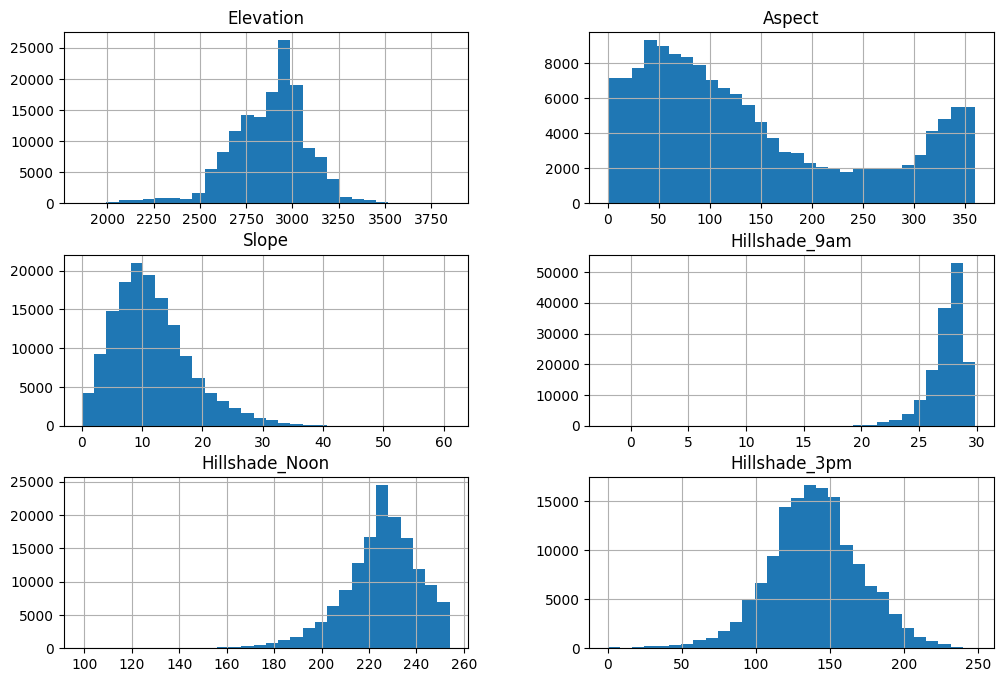

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

df[continuous[:6]].hist(figsize=(12,8), bins=30)
plt.show()

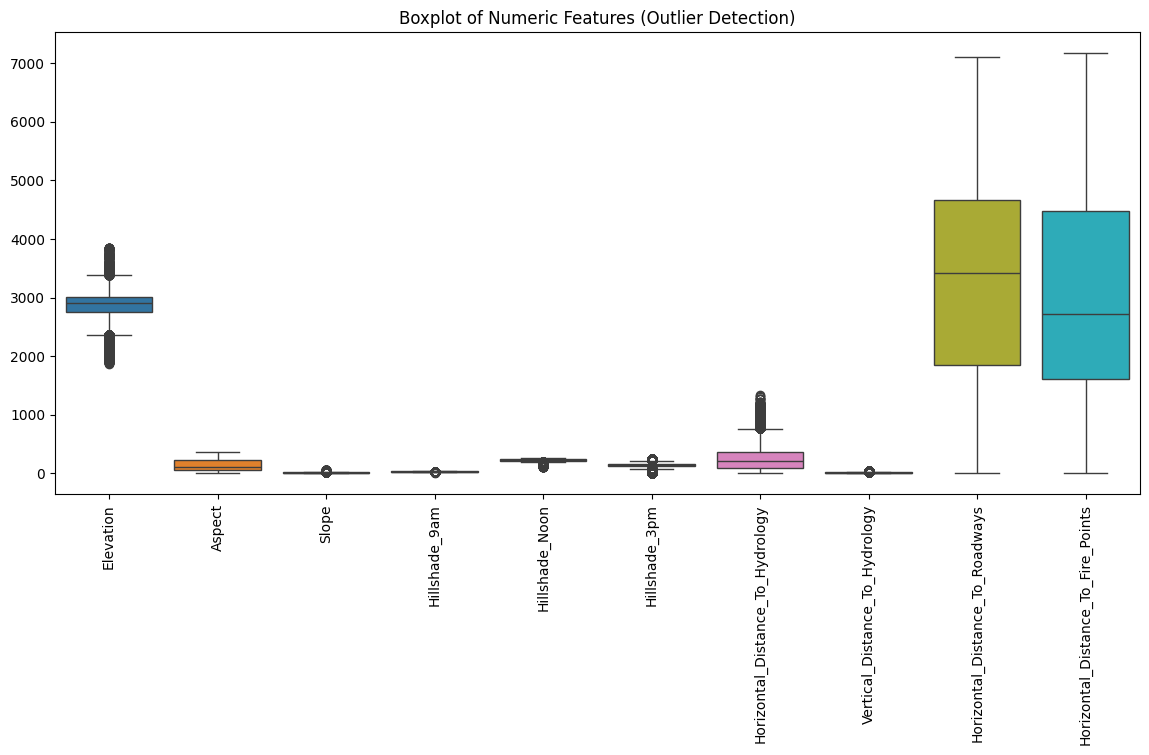

In [30]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df[continuous])
plt.xticks(rotation=90)
plt.title("Boxplot of Numeric Features (Outlier Detection)")
plt.show()

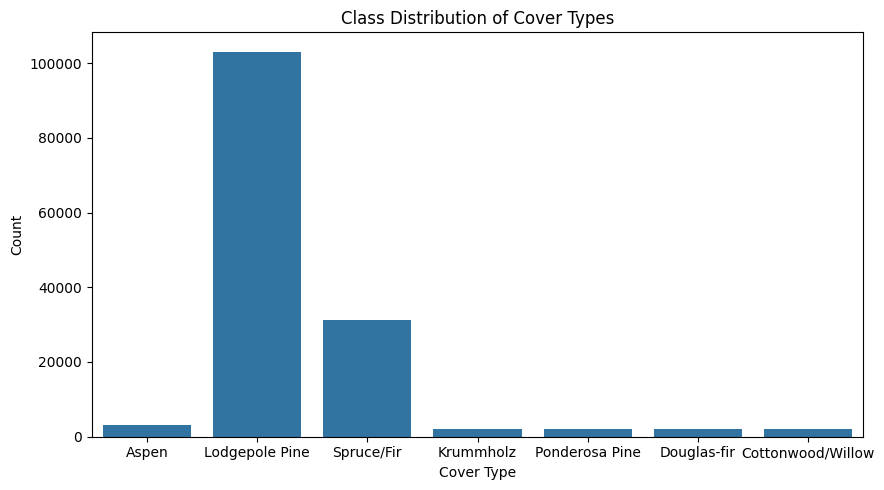

In [31]:
plt.figure(figsize=(9, 5))
sns.countplot(x="Cover_Type", data=df)
plt.title("Class Distribution of Cover Types")
plt.xlabel("Cover Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


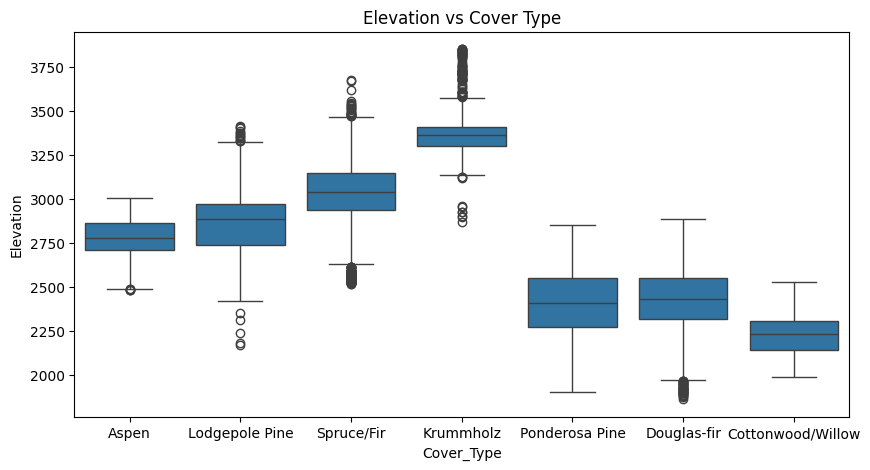

In [32]:
plt.figure(figsize=(10, 5))
sns.boxplot(x="Cover_Type", y="Elevation", data=df)
plt.title("Elevation vs Cover Type")
plt.show()

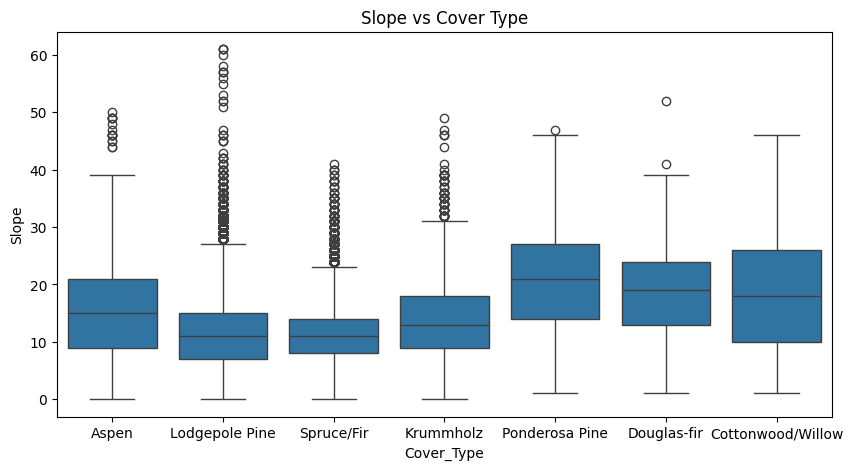

In [33]:
plt.figure(figsize=(10, 5))
sns.boxplot(x="Cover_Type", y="Slope", data=df)
plt.title("Slope vs Cover Type")
plt.show()

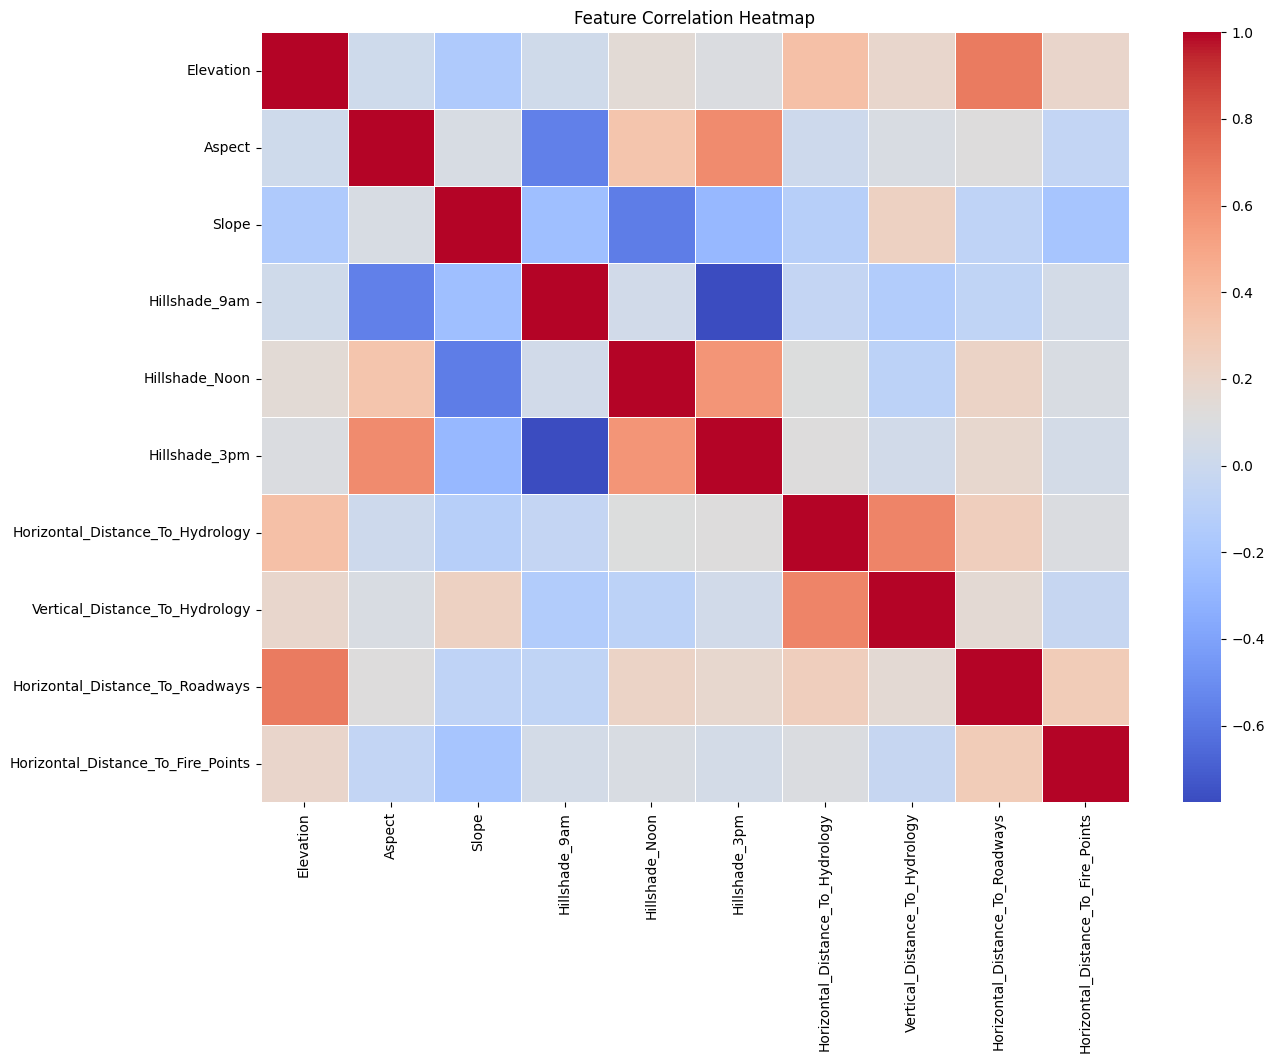

In [34]:
plt.figure(figsize=(14,10))
corr = df[continuous].corr()

sns.heatmap(corr, cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()


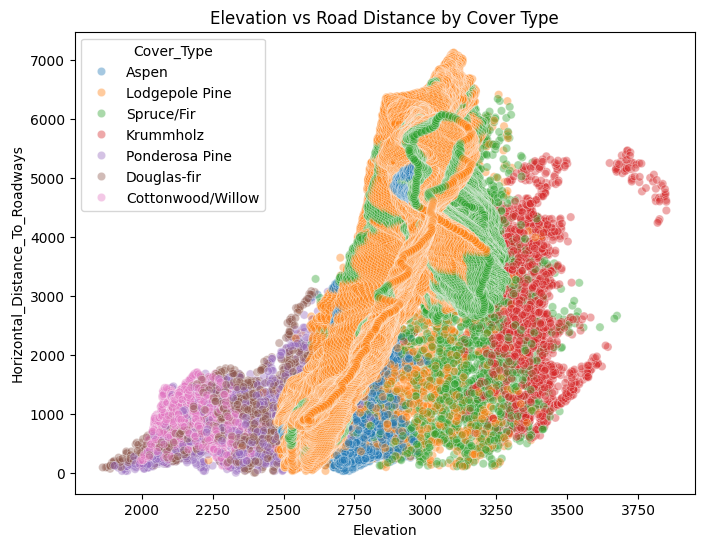

In [35]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x="Elevation",
    y="Horizontal_Distance_To_Roadways",
    hue="Cover_Type",
    data=df,
    alpha=0.4
)
plt.title("Elevation vs Road Distance by Cover Type")
plt.show()

In [36]:
#Feature engineering

skewed_features = [
    "Elevation",
    "Horizontal_Distance_To_Roadways",
    "Horizontal_Distance_To_Fire_Points",
    "Horizontal_Distance_To_Hydrology"
]

for col in skewed_features:
    df[col] = np.log1p(df[col])


In [37]:
df["Elevation_Slope_Interaction"] = df["Elevation"] * df["Slope"]

In [38]:
df["Hillshade_Diff_Morning_Noon"] = df["Hillshade_Noon"] - df["Hillshade_9am"]
df["Hillshade_Diff_Noon_Evening"] = df["Hillshade_Noon"] - df["Hillshade_3pm"]


In [39]:
df["Road_Fire_Ratio"] = (
    df["Horizontal_Distance_To_Roadways"] /
    (df["Horizontal_Distance_To_Fire_Points"] + 1)
)

df["Hydro_Road_Ratio"] = (
    df["Horizontal_Distance_To_Hydrology"] /
    (df["Horizontal_Distance_To_Roadways"] + 1)
)


In [63]:
df

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type,Wilderness_Area,Soil_Type,Elevation_Slope_Interaction,Hillshade_Diff_Morning_Noon,Hillshade_Diff_Noon_Evening,Road_Fire_Ratio,Hydro_Road_Ratio,Total_Distance
0,7.862112,51.0,3.0,5.556828,-2.000000,6.236370,27.732137,232.0,148.0,8.745125,Aspen,1.0,29.0,23.586337,204.267863,84.0,0.639948,0.767903,20.538323
1,7.859799,56.0,2.0,5.361292,NaN,5.968708,27.664794,235.0,151.0,8.736489,Aspen,1.0,29.0,15.719598,207.335206,84.0,0.613025,0.769338,20.066489
2,7.939159,139.0,9.0,5.594711,14.124515,8.064951,28.594117,238.0,135.0,8.719644,Lodgepole Pine,1.0,12.0,71.452429,209.405883,103.0,0.829758,0.617181,22.379306
3,7.932362,155.0,18.0,5.493061,19.725561,8.036250,28.854497,238.0,122.0,8.734238,Lodgepole Pine,1.0,30.0,142.782519,209.145503,116.0,0.825565,0.607892,22.263550
4,7.861727,45.0,2.0,5.036953,NaN,5.971262,27.664794,234.0,150.0,8.727940,Aspen,1.0,29.0,15.723454,206.335206,84.0,0.613826,0.722531,19.736155
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145885,7.949797,88.0,8.0,5.932245,11.266499,7.845024,28.463092,227.0,128.0,7.375256,Lodgepole Pine,1.0,29.0,63.598378,198.536908,99.0,0.936691,0.670687,21.152525
145886,7.949091,68.0,4.0,5.968708,11.266499,7.833204,27.933259,231.0,142.0,7.360740,Lodgepole Pine,1.0,29.0,31.796366,203.066741,89.0,0.936903,0.675713,21.162651
145887,7.948032,80.0,7.0,5.968708,9.489125,7.821242,28.265492,228.0,133.0,7.346655,Lodgepole Pine,1.0,29.0,55.636224,199.734508,95.0,0.937051,0.676629,21.136605
145888,7.946971,121.0,7.0,5.940171,8.954451,7.809135,28.463092,234.0,135.0,7.332369,Lodgepole Pine,1.0,29.0,55.628800,205.536908,99.0,0.937205,0.674319,21.081676


In [43]:
X=df.drop(columns=["Cover_Type"])
y=df["Cover_Type"]

In [44]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.pipeline import Pipeline as ImbPipeline   # ← replaces sklearn Pipeline
from imblearn.over_sampling import SMOTE

# ----------------------------------
# 1. Train-test split FIRST
#    (SMOTE will be applied inside pipeline, only on training data)
# ----------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ----------------------------------
# 2. Encode target labels for XGBoost
# ----------------------------------
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

# ----------------------------------
# 3. Feature separation
# ----------------------------------
num_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_features = X.select_dtypes(include=["object"]).columns.tolist()

# ----------------------------------
# 4. Preprocessing pipeline
#    Imputer is INSIDE pipeline → NaNs handled before SMOTE
# ----------------------------------
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler",  StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features)
])

# ----------------------------------
# 5. Models
# ----------------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN":                 KNeighborsClassifier(n_neighbors=5),
    "Decision Tree":       DecisionTreeClassifier(random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost":             XGBClassifier(
                               objective="multi:softprob" if len(np.unique(y)) > 2 else "binary:logistic",
                               eval_metric="mlogloss",
                               use_label_encoder=False,
                               random_state=42
                           )
}

# ----------------------------------
# 6. Train & evaluate using ImbPipeline
#    Order: preprocessor → SMOTE → model
#    SMOTE is skipped automatically at predict time
# ----------------------------------
trained_models = {}
results        = {}

for name, model in models.items():

    pipeline = ImbPipeline([
        ("preprocessor", preprocessor),           # Step 1: impute + scale + encode
        ("smote",        SMOTE(random_state=42)), # Step 2: balance classes (train only)
        ("model",        model)                   # Step 3: fit classifier
    ])

    if name == "XGBoost":
        pipeline.fit(X_train, y_train_enc)                        # encoded labels for XGB
        y_pred = le.inverse_transform(pipeline.predict(X_test))   # decode back to original
        results[name] = accuracy_score(y_test, y_pred)
    else:
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        results[name] = accuracy_score(y_test, y_pred)

    trained_models[name] = pipeline
    print(f"\n{name}")
    print(classification_report(
        y_test,
        y_pred if name != "XGBoost" else y_pred,
        zero_division=0
    ))

# ----------------------------------
# 7. Results summary
# ----------------------------------
results_df = (pd.DataFrame.from_dict(results, orient="index", columns=["Accuracy"])
                .sort_values("Accuracy", ascending=False))

print("\n===== Model Accuracy Comparison =====")
results_df


Logistic Regression
                   precision    recall  f1-score   support

            Aspen       0.13      0.71      0.22       614
Cottonwood/Willow       0.84      0.89      0.86       432
      Douglas-fir       0.63      0.65      0.64       432
        Krummholz       0.66      0.97      0.79       432
   Lodgepole Pine       0.88      0.66      0.75     20614
   Ponderosa Pine       0.63      0.62      0.63       432
       Spruce/Fir       0.48      0.66      0.56      6222

         accuracy                           0.67     29178
        macro avg       0.61      0.74      0.64     29178
     weighted avg       0.77      0.67      0.70     29178


KNN
                   precision    recall  f1-score   support

            Aspen       0.53      0.90      0.67       614
Cottonwood/Willow       0.94      0.94      0.94       432
      Douglas-fir       0.78      0.85      0.81       432
        Krummholz       0.81      0.97      0.88       432
   Lodgepole Pine       0.

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[04:41:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.





XGBoost
                   precision    recall  f1-score   support

            Aspen       0.77      0.95      0.85       614
Cottonwood/Willow       0.95      0.95      0.95       432
      Douglas-fir       0.83      0.87      0.85       432
        Krummholz       0.90      0.98      0.94       432
   Lodgepole Pine       0.96      0.94      0.95     20614
   Ponderosa Pine       0.83      0.85      0.84       432
       Spruce/Fir       0.84      0.86      0.85      6222

         accuracy                           0.92     29178
        macro avg       0.87      0.92      0.89     29178
     weighted avg       0.92      0.92      0.92     29178


===== Model Accuracy Comparison =====


,Accuracy
Random Forest,0.960038
Decision Tree,0.934985
XGBoost,0.922819
KNN,0.868531
Logistic Regression,0.665776


Hypertuning Random Forest with SMOTE...
Fitting 3 folds for each of 5 candidates, totalling 15 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning:

A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.




Best Params : {'model__max_depth': 30, 'model__max_features': 'log2', 'model__min_samples_split': 4, 'model__n_estimators': 249}
Best CV F1  : 0.9501

Before Tuning : 0.9600
After Tuning  : 0.9589
Improvement   : -0.0011

===== Classification Report =====
                   precision    recall  f1-score   support

            Aspen       0.86      0.93      0.89       614
Cottonwood/Willow       0.95      0.94      0.94       432
      Douglas-fir       0.83      0.87      0.85       432
        Krummholz       0.92      0.98      0.95       432
   Lodgepole Pine       0.98      0.97      0.98     20614
   Ponderosa Pine       0.83      0.87      0.85       432
       Spruce/Fir       0.91      0.94      0.93      6222

         accuracy                           0.96     29178
        macro avg       0.90      0.93      0.91     29178
     weighted avg       0.96      0.96      0.96     29178



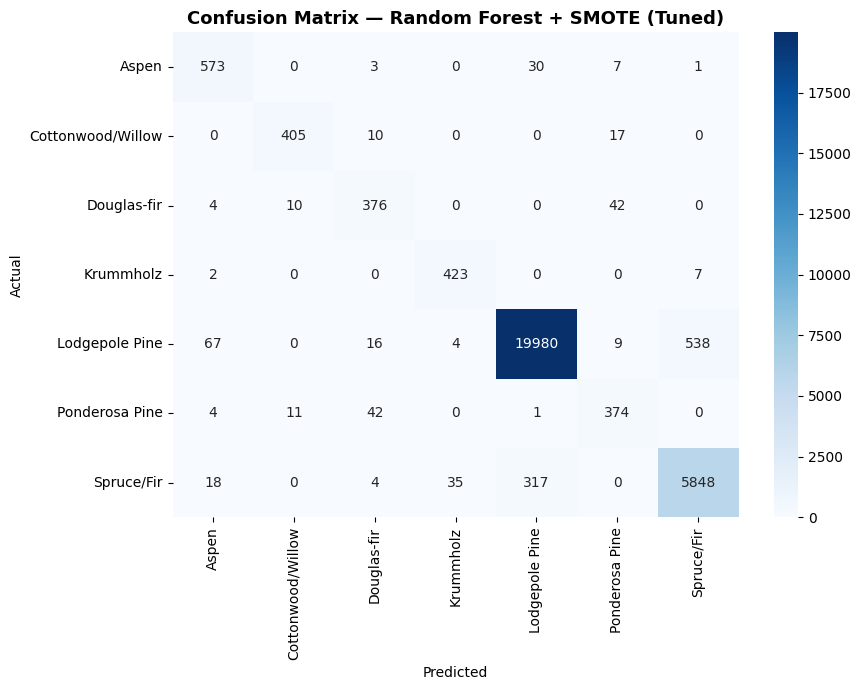

In [45]:
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import randint

# ----------------------------------
# 1. build Random Forest pipeline WITH SMOTE
# ----------------------------------
rf_pipeline = ImbPipeline([
    ("preprocessor", preprocessor),           # impute + scale + encode
    ("smote",        SMOTE(random_state=42)), # balance classes (train only)
    ("model",        RandomForestClassifier(random_state=42))
])

# ----------------------------------
# 2. Randomized param distributions
# ----------------------------------
param_dist = {
    "model__n_estimators":      randint(100, 300),
    "model__max_depth":         [None, 10, 20, 30],
    "model__min_samples_split": randint(2, 15),
    "model__max_features":      ["sqrt", "log2"]
}

# ----------------------------------
# 3. RandomizedSearchCV
#    SMOTE runs only on each training fold — never on validation fold
# ----------------------------------
random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_dist,
    n_iter=5,
    cv=3,
    scoring="f1_weighted",   # ← better than accuracy for imbalanced data
    n_jobs=-1,
    verbose=1,
    random_state=42
)

print("Hypertuning Random Forest with SMOTE...")
random_search.fit(X_train, y_train)   # raw X_train — pipeline handles everything

print(f"\nBest Params : {random_search.best_params_}")
print(f"Best CV F1  : {random_search.best_score_:.4f}")

# ----------------------------------
# 4. Evaluate on test set
#    SMOTE is automatically skipped at predict time
# ----------------------------------
tuned_rf     = random_search.best_estimator_
y_pred_tuned = tuned_rf.predict(X_test)

tuned_acc = accuracy_score(y_test, y_pred_tuned)
base_acc  = results["Random Forest"]

print(f"\nBefore Tuning : {base_acc:.4f}")
print(f"After Tuning  : {tuned_acc:.4f}")
print(f"Improvement   : {tuned_acc - base_acc:+.4f}")

# ----------------------------------
# 5. Classification report
# ----------------------------------
print("\n===== Classification Report =====")
print(classification_report(y_test, y_pred_tuned))

# ----------------------------------
# 6. Confusion matrix
# ----------------------------------
cm     = confusion_matrix(y_test, y_pred_tuned)
labels = sorted(y.unique())

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_title("Confusion Matrix — Random Forest + SMOTE (Tuned)", fontsize=13, fontweight="bold")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

In [48]:
import joblib

# best trained pipeline
best_model = random_search.best_estimator_

# save model
joblib.dump(best_model, "rf_smote_pipeline.pkl")

print("Model saved successfully")

Model saved successfully


In [49]:
!pip install streamlit streamlit_option_menu  # installing streamlit and streamlit_option_menu packages

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.3/829.3 kB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 88.7 MB/s eta 0:00:00


In [60]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib

# -----------------------------
# Load trained pipeline
# -----------------------------
model = joblib.load("rf_smote_pipeline.pkl")

st.title("🌲 Forest Cover Type Prediction")

st.write("Enter the environmental features to predict the forest cover type.")

# -----------------------------
# User Inputs
# -----------------------------

Elevation = st.number_input("Elevation", min_value=1, max_value=120, value=30)
Aspect = st.number_input("Aspect", min_value=1, max_value=120, value=30)
Slope = st.number_input("Slope", min_value=1, max_value=120, value=30)

Horizontal_Distance_To_Hydrology = st.number_input("Horizontal Distance To Hydrology", min_value=1, max_value=120, value=30)
Vertical_Distance_To_Hydrology = st.number_input("Vertical Distance To Hydrology", min_value=1, max_value=120, value=30)

Horizontal_Distance_To_Roadways = st.number_input("Horizontal Distance To Roadways", min_value=1, max_value=120, value=30)

Hillshade_9am = st.number_input("Hillshade 9am", min_value=1, max_value=120, value=30)
Hillshade_Noon = st.number_input("Hillshade Noon", min_value=1, max_value=120, value=30)
Hillshade_3pm = st.number_input("Hillshade 3pm", min_value=1, max_value=120, value=30)

Horizontal_Distance_To_Fire_Points = st.number_input("Horizontal Distance To Fire Points", min_value=1, max_value=120, value=30)

# -----------------------------
# Predict Button
# -----------------------------

if st.button("Predict Cover Type"):

    input_data = pd.DataFrame({
        "Elevation":[Elevation],
        "Aspect":[Aspect],
        "Slope":[Slope],
        "Horizontal_Distance_To_Hydrology":[Horizontal_Distance_To_Hydrology],
        "Vertical_Distance_To_Hydrology":[Vertical_Distance_To_Hydrology],
        "Horizontal_Distance_To_Roadways":[Horizontal_Distance_To_Roadways],
        "Hillshade_9am":[Hillshade_9am],
        "Hillshade_Noon":[Hillshade_Noon],
        "Hillshade_3pm":[Hillshade_3pm],
        "Horizontal_Distance_To_Fire_Points":[Horizontal_Distance_To_Fire_Points]
    })

    prediction = model.predict(input_data)

    st.success(f"Predicted Forest Cover Type: {prediction[0]}")

Overwriting app.py


In [56]:
# @title Setup code
!pip install -q streamlit
!wget https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared-linux-amd64
import subprocess
subprocess.Popen(["./cloudflared-linux-amd64", "tunnel", "--url", "http://localhost:8501"])
!nohup /content/cloudflared-linux-amd64 tunnel --url http://localhost:8501 &

--2026-03-05 06:37:12--  https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/cloudflare/cloudflared/releases/download/2026.2.0/cloudflared-linux-amd64 [following]
--2026-03-05 06:37:12--  https://github.com/cloudflare/cloudflared/releases/download/2026.2.0/cloudflared-linux-amd64
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/106867604/f9298ca8-89c8-41fe-a51f-e24cb2059878?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-03-05T07%3A20%3A03Z&rscd=attachment%3B+filename%3Dcloudflared-linux-amd64&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-03-05

In [57]:
!streamlit run /content/app.py &>/content/logs.txt &

In [58]:
!grep -o 'https://.*\.trycloudflare.com' nohup.out | head -n 1 | xargs -I {} echo "Your tunnel url {}"

Your tunnel url https://wrap-robust-total-spirits.trycloudflare.com
